# Transformer from Scratch: Math, Intuition, and Mini GPT Implementation

## What You Will Learn

- What is a Transformer?
- Mathematical intuition behind Attention
- Implementing Self-Attention from scratch (NumPy)
- Multi-Head Attention
- Positional Encoding
- Building a Mini GPT (PyTorch)
- Training and Visualization

This notebook is designed to build **deep intuition + practical skills**.

## Why Transformers?

Traditional models:
- RNN → sequential, slow
- LSTM → limited long-term memory

Transformer:
- Parallel processing
- Global context awareness

Key idea:
> Each word looks at every other word and decides importance

In [1]:
import numpy as np

# Example sentence
tokens = ["I", "love", "AI"]

# Fake embedding (for demonstration)
X = np.array([
    [1, 0, 1, 0],
    [0, 2, 0, 2],
    [1, 1, 1, 1]
])

X

array([[1, 0, 1, 0],
       [0, 2, 0, 2],
       [1, 1, 1, 1]])

Each word is now a vector → numerical representation of meaning

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In [2]:
d_model = 4

W_Q = np.random.randn(d_model, d_model)
W_K = np.random.randn(d_model, d_model)
W_V = np.random.randn(d_model, d_model)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

scores = Q @ K.T
scores = scores / np.sqrt(d_model)

In [3]:
def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)

A = softmax(scores)

In [4]:
output = A @ V
output

array([[-0.76131434, -1.64004959,  1.6790298 ,  0.55134108],
       [-1.39710926, -4.89896989, -0.46758644, -1.91425748],
       [-0.74750088, -1.68277074,  1.51242063,  0.42908492]])

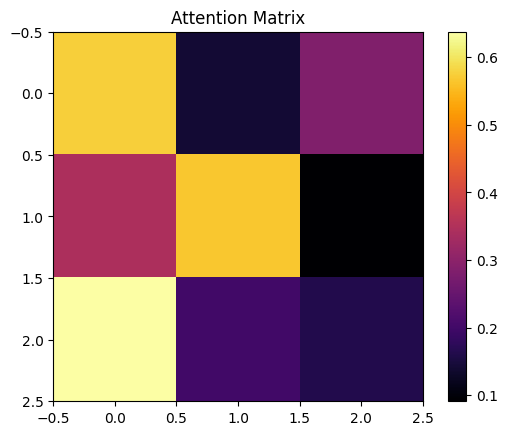

In [5]:
import matplotlib.pyplot as plt

plt.imshow(A, cmap='inferno')
plt.colorbar()
plt.title("Attention Matrix")
plt.show()

- Rows = query words  
- Columns = key words  
- Bright = strong attention  

Instead of one attention, we use multiple heads.

Each head learns different relationships.

In [6]:
num_heads = 2
head_dim = d_model // num_heads

def split_heads(X):
    return X.reshape(X.shape[0], num_heads, head_dim)

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

$$
PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

## Positional Encoding (Very Simple Explanation)

Transformers do not understand word order by default.  
So we add **positional encoding** to give each word a sense of position.

### Idea
Each position is converted into a unique pattern using sine and cosine functions.

- Even index (2i): use sine  
- Odd index (2i + 1): use cosine  

### Why do we do this?

1. **To give order information**  
   The model can tell which word comes first, second, etc.

2. **Nearby positions look similar**  
   This helps the model understand distance between words.

3. **No training needed**  
   These values are fixed and do not need to be learned.

### Intuition

Each word gets a special wave-like pattern based on its position.  
The model uses this pattern to understand where the word is in the sentence.

Without this, the sentence:
"I love AI"  
and  
"AI love I"  

would look the same to the Transformer.

In [7]:
def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            PE[pos, i] = np.sin(pos / (10000 ** (i/d_model)))
            PE[pos, i+1] = np.cos(pos / (10000 ** (i/d_model)))
    return PE

PE = positional_encoding(3, 4)
X_pos = X + PE

## PyTorch Implementation

In [8]:
import torch
import torch.nn as nn
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Self-Attention Module

In [9]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(C)

        
        mask = torch.tril(torch.ones(T, T, device=x.device))
        scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = torch.softmax(scores, dim=-1)

        return attn @ V

# Transformer Block

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.attn = SelfAttention(d_model)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.ReLU(),
            nn.Linear(4*d_model, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

## Mini GPT Model

In [11]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model, heads, layers, max_len):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        self.blocks = nn.Sequential(*[
            TransformerBlock(d_model, heads) for _ in range(layers)
        ])

        self.ln = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape

        
        pos = torch.arange(0, T, device=x.device).unsqueeze(0)

        x = self.token_emb(x) + self.pos_emb(pos)
        x = self.blocks(x)
        x = self.ln(x)

        return self.fc(x)

In [12]:
import torch


x = torch.randint(0, 100, (2, 5))
y = torch.randint(0, 100, (2, 5))

In [13]:
model = MiniGPT(vocab_size=100, d_model=64, heads=4, layers=2, max_len=50)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

In [14]:
for epoch in range(10):
    logits = model(x)

    loss = criterion(logits.view(-1, 100), y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(loss.item())

4.612624168395996
4.503304481506348
4.394753456115723
4.287271499633789
4.1809186935424805
4.075774192810059
3.971890926361084
3.8694522380828857
3.7685294151306152
3.669234037399292


$$
lr = d_{model}^{-0.5} \cdot \min\left(step^{-0.5}, \; step \cdot warmup^{-1.5}\right)
$$

In [15]:
import pandas as pd

# Load datasets
train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/validation.csv")
test_df  = pd.read_csv("data/test.csv")

print(train_df.head())

                                                text
0  First Citizen:\nBefore we proceed any further,...


In [16]:
print(train_df.columns)

Index(['text'], dtype='str')


In [17]:
train_text = " ".join(train_df["text"].astype(str).tolist())
val_text   = " ".join(val_df["text"].astype(str).tolist())
test_text  = " ".join(test_df["text"].astype(str).tolist())

print(train_text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## Tokenization(Character)

In [18]:
import torch


chars = sorted(list(set(train_text)))
vocab_size = len(chars)

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}

print("Vocab size:", vocab_size)

Vocab size: 65


In [19]:
# encode dataset
train_data = torch.tensor([stoi[ch] for ch in train_text if ch in stoi], dtype=torch.long)
val_data   = torch.tensor([stoi[ch] for ch in val_text if ch in stoi], dtype=torch.long)

print(train_data[:50])

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56])


## Batch Loader

In [20]:
block_size = 128   # increase for better context
batch_size = 32

def get_batch(split):
    data = train_data if split == 'train' else val_data

    ix = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return x, y

## Model Initialization

In [21]:
model = MiniGPT(
    vocab_size=vocab_size,
    d_model=128,
    heads=4,
    layers=3,
    max_len=block_size
).to(device)

In [22]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = torch.nn.CrossEntropyLoss()

train_losses = []
val_losses = []

for step in range(10000):  
    xb, yb = get_batch('train')
    xb, yb = xb.to(device), yb.to(device)

    logits = model(xb)
    B, T, C = logits.shape

    loss = criterion(logits.view(B*T, C), yb.view(B*T))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if step % 200 == 0:
        with torch.no_grad():
            xb_val, yb_val = get_batch('val')
            xb_val, yb_val = xb_val.to(device), yb_val.to(device)

            val_logits = model(xb_val)
            val_loss = criterion(val_logits.view(-1, vocab_size), yb_val.view(-1))

            val_losses.append(val_loss.item())

        print(f"Step {step} | Train {loss.item():.4f} | Val {val_loss.item():.4f}")

Step 0 | Train 4.3509 | Val 4.2178
Step 200 | Train 2.5344 | Val 2.5696
Step 400 | Train 2.4301 | Val 2.4673
Step 600 | Train 2.3307 | Val 2.3744
Step 800 | Train 2.2582 | Val 2.2382
Step 1000 | Train 2.1783 | Val 2.2124
Step 1200 | Train 2.0989 | Val 2.0856
Step 1400 | Train 1.9774 | Val 2.0214
Step 1600 | Train 1.9298 | Val 2.0063
Step 1800 | Train 1.9215 | Val 2.0206
Step 2000 | Train 1.8345 | Val 1.9585
Step 2200 | Train 1.8133 | Val 1.9035
Step 2400 | Train 1.7684 | Val 1.8554
Step 2600 | Train 1.7321 | Val 1.8145
Step 2800 | Train 1.6992 | Val 1.8724
Step 3000 | Train 1.7147 | Val 1.7665
Step 3200 | Train 1.6089 | Val 1.7858
Step 3400 | Train 1.6367 | Val 1.7602
Step 3600 | Train 1.5825 | Val 1.7454
Step 3800 | Train 1.6065 | Val 1.7600
Step 4000 | Train 1.5580 | Val 1.7022
Step 4200 | Train 1.5561 | Val 1.7410
Step 4400 | Train 1.5671 | Val 1.7109
Step 4600 | Train 1.5156 | Val 1.6719
Step 4800 | Train 1.5437 | Val 1.6553
Step 5000 | Train 1.5334 | Val 1.6526
Step 5200 | Train 1

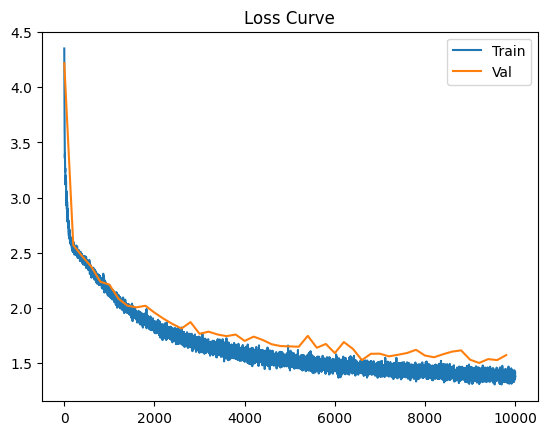

In [23]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(range(0, len(train_losses), 200), val_losses, label="Val")
plt.legend()
plt.title("Loss Curve")
plt.show()

## Generate Text

In [24]:
def generate(model, start_idx, max_new_tokens=300):
    model.eval()

    x = torch.tensor([[start_idx]], device=device)

    for _ in range(max_new_tokens):
        x_cond = x[:, -block_size:]

        logits = model(x_cond)
        logits = logits[:, -1, :]

        
        temperature = 0.8
        probs = torch.softmax(logits / temperature, dim=-1)

        
        k = 10
        topk_probs, topk_indices = torch.topk(probs, k)

        next_token = topk_indices[0, torch.multinomial(topk_probs[0], 1)]

        x = torch.cat([x, next_token.unsqueeze(0)], dim=1)

    return x

In [25]:
start_char = 'T' if 'T' in stoi else list(stoi.keys())[0]
start_idx = stoi[start_char]

generated = generate(model, start_idx)

result = ''.join([itos[i.item()] for i in generated[0]])
print(result)

TUS:
And for his fair, I am it, but in the world of lame,
His way speed in his death and made on thou hast thou wilt be conspect.

DUCHESS OF YORK:
I do the stop of thy suit was my country.

KING RICHARD III:
Why, is a humour with the fix'd;
And thou desperain pack who was a dare to ask
If the world 


In [26]:
test_data = torch.tensor([stoi[ch] for ch in test_text if ch in stoi], dtype=torch.long)

def evaluate(data):
    losses = []
    for _ in range(50):
        ix = torch.randint(len(data) - block_size, (batch_size,))
        x = torch.stack([data[i:i+block_size] for i in ix]).to(device)
        y = torch.stack([data[i+1:i+block_size+1] for i in ix]).to(device)

        with torch.no_grad():
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))

        losses.append(loss.item())

    return sum(losses)/len(losses)

print("Test Loss:", evaluate(test_data))

Test Loss: 1.691594786643982


##  Learning Rate Warmup

$$
lr = d_{model}^{-0.5} \cdot \min\left(step^{-0.5}, \; step \cdot warmup^{-1.5}\right)
$$

This learning rate schedule gradually increases the learning rate at the start of training (warmup phase) and then decreases it over time.

### Why it is used
- Stabilizes early training when weights are random  
- Prevents large gradient shocks at the beginning  
- Helps Transformers converge more reliably  
- Widely used in modern Transformer architectures  


This notebook implemented:

✔ Attention mechanism from scratch  
✔ Full Transformer architecture  
✔ GPT-style training loop  
✔ Dataset preprocessing and batching  
✔ Generate Text



This system demonstrates the complete pipeline of a Transformer-based language model — from raw text processing to training and generation — forming the foundation of modern NLP systems.